# Speech Commands v2 data exploration

Download and poke at the dataset before writing `src/data.py`.

Kaggle mirror used: [`sylkaladin/speech-commands-v2`](https://www.kaggle.com/datasets/sylkaladin/speech-commands-v2) (Google Speech Commands v0.02, 35 classes, 16kHz mono wav).

In [10]:
!uv pip install -q kagglehub librosa soundfile matplotlib

In [11]:
import kagglehub

# Requires a Kaggle account: kagglehub will prompt for a kaggle.json API token
# on first run (or set KAGGLE_USERNAME / KAGGLE_KEY env vars).
DATASET_SLUG = "sylkaladin/speech-commands-v2"

dataset_path = kagglehub.dataset_download(DATASET_SLUG)
print("Downloaded to:", dataset_path)

/home/maksim/PycharmProjects/kws-accent-robustness/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 2.25G/2.25G [03:17<00:00, 12.3MB/s] 

Extracting files...


Downloaded to: /home/maksim/.cache/kagglehub/datasets/sylkaladin/speech-commands-v2/versions/1


In [12]:
from pathlib import Path

root = Path(dataset_path)
for p in sorted(root.iterdir()):
    print(p)

/home/maksim/.cache/kagglehub/datasets/sylkaladin/speech-commands-v2/versions/1/LICENSE
/home/maksim/.cache/kagglehub/datasets/sylkaladin/speech-commands-v2/versions/1/README.md
/home/maksim/.cache/kagglehub/datasets/sylkaladin/speech-commands-v2/versions/1/_background_noise_
/home/maksim/.cache/kagglehub/datasets/sylkaladin/speech-commands-v2/versions/1/backward
/home/maksim/.cache/kagglehub/datasets/sylkaladin/speech-commands-v2/versions/1/bed
/home/maksim/.cache/kagglehub/datasets/sylkaladin/speech-commands-v2/versions/1/bird
/home/maksim/.cache/kagglehub/datasets/sylkaladin/speech-commands-v2/versions/1/cat
/home/maksim/.cache/kagglehub/datasets/sylkaladin/speech-commands-v2/versions/1/dog
/home/maksim/.cache/kagglehub/datasets/sylkaladin/speech-commands-v2/versions/1/down
/home/maksim/.cache/kagglehub/datasets/sylkaladin/speech-commands-v2/versions/1/eight
/home/maksim/.cache/kagglehub/datasets/sylkaladin/speech-commands-v2/versions/1/five
/home/maksim/.cache/kagglehub/datasets/sy

In [13]:
data_root = root  # adjust if the wavs live in a subfolder, e.g. root / "speech_commands_v0.02"

labels = sorted(
    d.name for d in data_root.iterdir()
    if d.is_dir() and not d.name.startswith("_")
)
print(f"{len(labels)} labels:", labels)

35 labels: ['backward', 'bed', 'bird', 'cat', 'dog', 'down', 'eight', 'five', 'follow', 'forward', 'four', 'go', 'happy', 'house', 'learn', 'left', 'marvin', 'nine', 'no', 'off', 'on', 'one', 'right', 'seven', 'sheila', 'six', 'stop', 'three', 'tree', 'two', 'up', 'visual', 'wow', 'yes', 'zero']


In [14]:
# _background_noise_ holds long-form noise clips used for augmentation, not a label
noise_dir = data_root / "_background_noise_"
if noise_dir.exists():
    print(list(noise_dir.iterdir()))

[PosixPath('/home/maksim/.cache/kagglehub/datasets/sylkaladin/speech-commands-v2/versions/1/_background_noise_/exercise_bike.wav'), PosixPath('/home/maksim/.cache/kagglehub/datasets/sylkaladin/speech-commands-v2/versions/1/_background_noise_/README.md'), PosixPath('/home/maksim/.cache/kagglehub/datasets/sylkaladin/speech-commands-v2/versions/1/_background_noise_/pink_noise.wav'), PosixPath('/home/maksim/.cache/kagglehub/datasets/sylkaladin/speech-commands-v2/versions/1/_background_noise_/running_tap.wav'), PosixPath('/home/maksim/.cache/kagglehub/datasets/sylkaladin/speech-commands-v2/versions/1/_background_noise_/dude_miaowing.wav'), PosixPath('/home/maksim/.cache/kagglehub/datasets/sylkaladin/speech-commands-v2/versions/1/_background_noise_/doing_the_dishes.wav'), PosixPath('/home/maksim/.cache/kagglehub/datasets/sylkaladin/speech-commands-v2/versions/1/_background_noise_/white_noise.wav')]


In [15]:
val_list = data_root / "validation_list.txt"
test_list = data_root / "testing_list.txt"

for f in (val_list, test_list):
    if f.exists():
        lines = f.read_text().splitlines()
        print(f.name, "->", len(lines), "entries, e.g.", lines[:3])
    else:
        print(f.name, "NOT FOUND at", f)

validation_list.txt -> 9981 entries, e.g. ['right/a69b9b3e_nohash_0.wav', 'right/439c84f4_nohash_1.wav', 'right/409c962a_nohash_1.wav']
testing_list.txt -> 11005 entries, e.g. ['right/bb05582b_nohash_3.wav', 'right/97f4c236_nohash_2.wav', 'right/f2e59fea_nohash_3.wav']


label: happy | file: 19b05529_nohash_0.wav | sr: 16000 | duration (s): 1.0


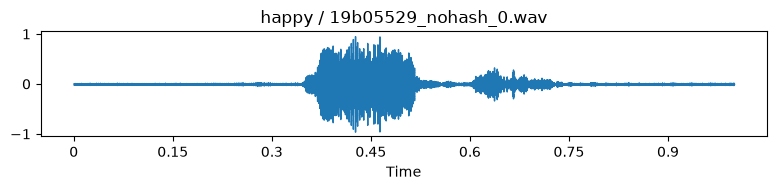

In [16]:
import random
import librosa
import librosa.display
import matplotlib.pyplot as plt

sample_label = random.choice(labels)
sample_wav = random.choice(list((data_root / sample_label).glob("*.wav")))

y, sr = librosa.load(sample_wav, sr=16000)
print("label:", sample_label, "| file:", sample_wav.name, "| sr:", sr, "| duration (s):", len(y) / sr)

plt.figure(figsize=(8, 2))
librosa.display.waveshow(y, sr=sr)
plt.title(f"{sample_label} / {sample_wav.name}")
plt.tight_layout()
plt.show()

In [17]:
from collections import Counter

counts = Counter()
for label in labels:
    counts[label] = len(list((data_root / label).glob("*.wav")))

for label, n in sorted(counts.items(), key=lambda kv: -kv[1]):
    print(f"{label:12s} {n}")

five         4052
zero         4052
yes          4044
seven        3998
no           3941
nine         3934
down         3917
one          3890
go           3880
two          3880
stop         3872
six          3860
on           3845
left         3801
eight        3787
right        3778
off          3745
four         3728
three        3727
up           3723
dog          2128
wow          2123
house        2113
marvin       2100
bird         2064
happy        2054
cat          2031
sheila       2022
bed          2014
tree         1759
backward     1664
visual       1592
follow       1579
learn        1575
forward      1557
